In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Data Wrangling Function
def wrangle(filepath):
    df = pd.read_csv(filepath)

    # Clean column names
    df.columns = df.columns.str.strip().str.replace(" ", "_")

    # Remove leakage variables
    df = df.drop(columns=["Position", "Time/Retired"], errors="ignore")

    # Convert Yes/No to binary
    df["Set_Fastest_Lap"] = df["Set_Fastest_Lap"].map({"Yes": 1, "No": 0})

    # Convert fastest lap time into seconds
    def lap_to_seconds(x):
        if pd.isna(x):
            return np.nan
        try:
            minutes, seconds = str(x).split(":")
            return int(minutes) * 60 + float(seconds)
        except:
            return np.nan

    df["Fastest_Lap_Seconds"] = df["Fastest_Lap_Time"].apply(lap_to_seconds)
    df = df.drop(columns=["Fastest_Lap_Time"], errors="ignore")

    # Drop rows with missing values
    df = df.dropna()

    return df

In [3]:
# Load data
df = wrangle("F1_2025_RaceResults.csv")

df.head()

,Track,No,Driver,Team,Starting_Grid,Laps,Points,Set_Fastest_Lap,Fastest_Lap_Seconds
0,Australia,4,Lando Norris,McLaren Mercedes,1,57,25,1,82.167
1,Australia,1,Max Verstappen,Red Bull Racing Honda RBPT,3,57,18,0,83.081
2,Australia,63,George Russell,Mercedes,4,57,15,0,85.065
3,Australia,12,Kimi Antonelli,Mercedes,16,57,12,0,84.901
4,Australia,23,Alexander Albon,Williams Mercedes,6,57,10,0,84.597


In [4]:
# Exploratory Data Analysis
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 173 entries, 0 to 178
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Track                173 non-null    object 
 1   No                   173 non-null    int64  
 2   Driver               173 non-null    object 
 3   Team                 173 non-null    object 
 4   Starting_Grid        173 non-null    int64  
 5   Laps                 173 non-null    int64  
 6   Points               173 non-null    int64  
 7   Set_Fastest_Lap      173 non-null    int64  
 8   Fastest_Lap_Seconds  173 non-null    float64
dtypes: float64(1), int64(5), object(3)
memory usage: 13.5+ KB


,No,Starting_Grid,Laps,Points,Set_Fastest_Lap,Fastest_Lap_Seconds
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,28.826590,10.427746,55.930636,5.254335,0.052023,87.330566
std,25.042382,5.837104,14.047090,7.263644,0.222718,7.921941
min,1.000000,1.000000,0.000000,0.000000,0.000000,73.221000
25%,10.000000,5.000000,53.000000,0.000000,0.000000,79.424000
50%,22.000000,10.000000,57.000000,1.000000,0.000000,90.965000
75%,44.000000,16.000000,63.000000,10.000000,0.000000,93.446000
max,87.000000,20.000000,78.000000,25.000000,1.000000,99.256000


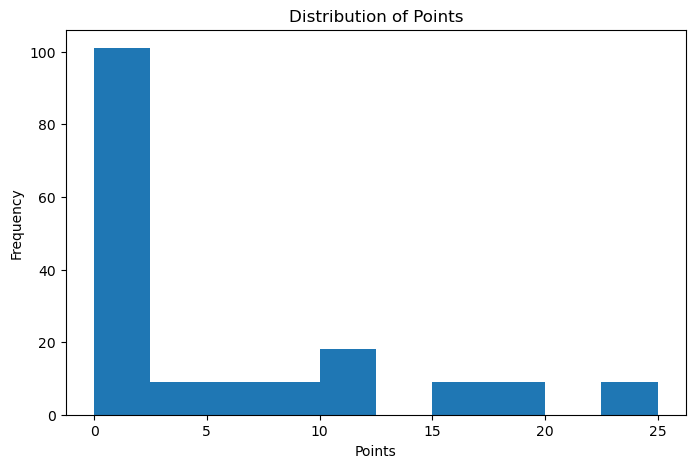

In [5]:
# Points distribution
plt.figure(figsize=(8,5))
plt.hist(df["Points"], bins=10)
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.title("Distribution of Points")
plt.show()

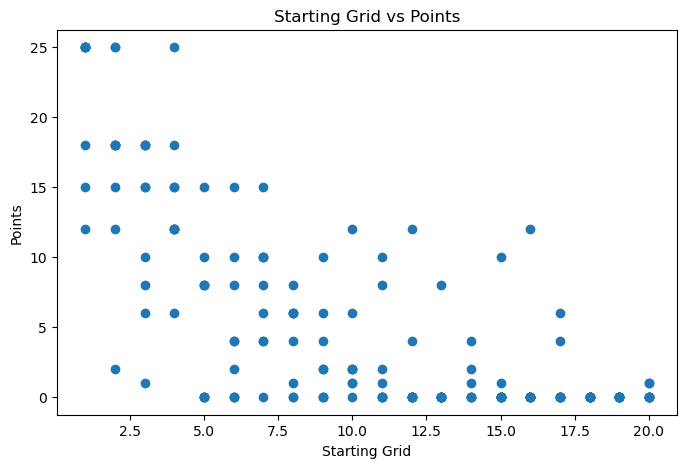

In [6]:
# Starting Grid vs Points
plt.figure(figsize=(8,5))
plt.scatter(df["Starting_Grid"], df["Points"])
plt.xlabel("Starting Grid")
plt.ylabel("Points")
plt.title("Starting Grid vs Points")
plt.show()

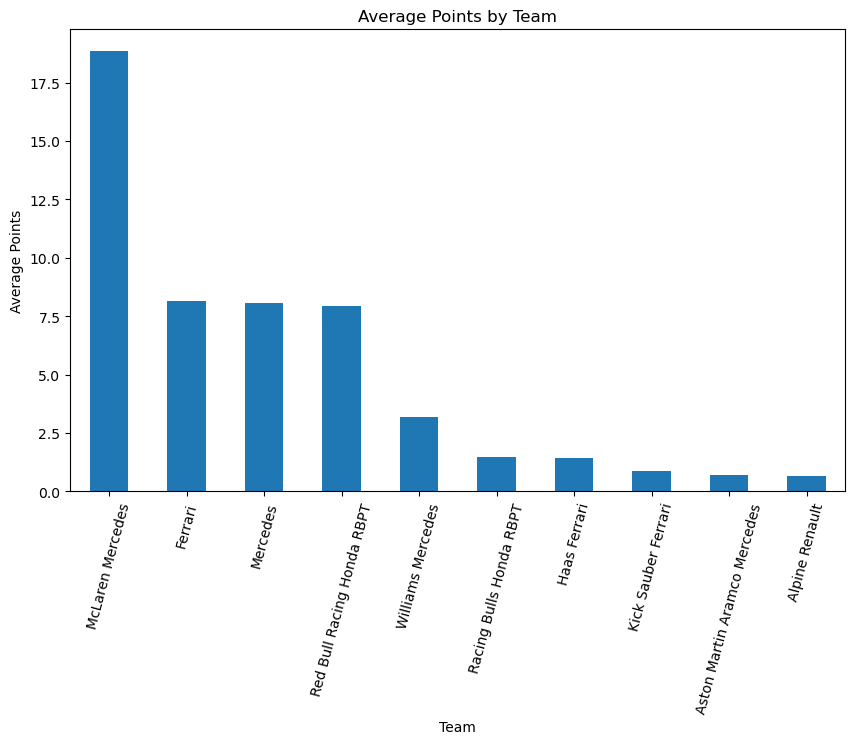

In [7]:
# Average points by team
team_points = df.groupby("Team")["Points"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
team_points.plot(kind="bar")
plt.xlabel("Team")
plt.ylabel("Average Points")
plt.title("Average Points by Team")
plt.xticks(rotation=75)
plt.show()

In [8]:
# Train-Test Split
X = df.drop(columns=["Points"])
y = df["Points"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [9]:
# Model Predicting race points
categorical_features = ["Track", "Driver", "Team"]
numeric_features = ["No", "Starting_Grid", "Laps", "Set_Fastest_Lap", "Fastest_Lap_Seconds"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(random_state=42, n_estimators=200))
    ]
)

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
# Model Evaluation
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("R-squared:", round(r2, 3))

RMSE: 3.202
MAE: 2.138
R-squared: 0.799


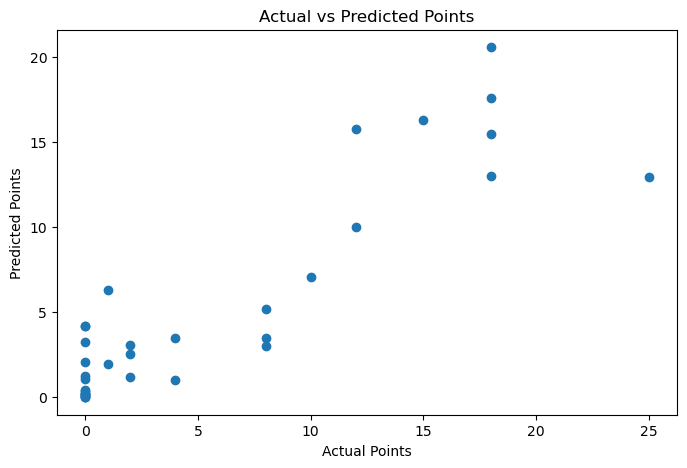

In [11]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Actual vs Predicted Points")
plt.show()

In [12]:
# 7. Feature Importance
rf = model.named_steps["regressor"]

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

importance_df

,Feature,Importance
41,num__Starting_Grid,0.620749
35,cat__Team_McLaren Mercedes,0.077950
44,num__Fastest_Lap_Seconds,0.053910
40,num__No,0.039507
32,cat__Team_Ferrari,0.029151
0,cat__Track_Australia,0.027622
42,num__Laps,0.025843
8,cat__Track_Spain,0.011526
5,cat__Track_Miami,0.011012
43,num__Set_Fastest_Lap,0.009561


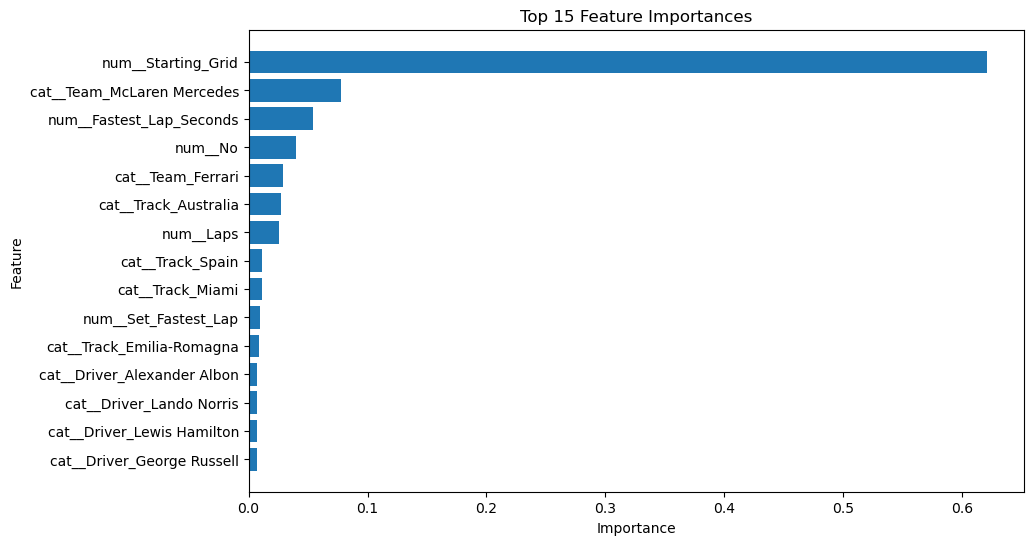

In [13]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Conclusion/Findings
1. Starting grid position was one of the strongest predictors of race points.
Drivers who started closer to the front of the grid generally earned more points.

2. Team performance had a major impact on results. Top teams consistently
scored higher average points than lower ranked teams.

3. Drivers who achieved the fastest lap or maintained faster lap times
tended to finish with higher point totals.

4. The Random Forest model performed well because it captured nonlinear
relationships between race conditions, driver skill, and team performance.

5. Feature importance results showed that variables related to race pace,
starting position, and team strength contributed the most to predicting points.

6. The Actual vs Predicted plot showed that most predictions followed the
overall trend of the observed values, showing the model was reasonably accurate.

7. Some prediction error remained because Formula 1 races contain uncertainty
such as crashes, penalties, weather conditions, and mechanical failures that
are difficult to fully capture in the dataset.